# Vitenskapelige beregninger - simulasjon av fase seperasjon i en binær blanding

## Oppgave 1

In [73]:
# Importerer alle nødvendige bibliotek
%matplotlib inline
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift
import project_tools as pt
from IPython.display import HTML

### 1.1

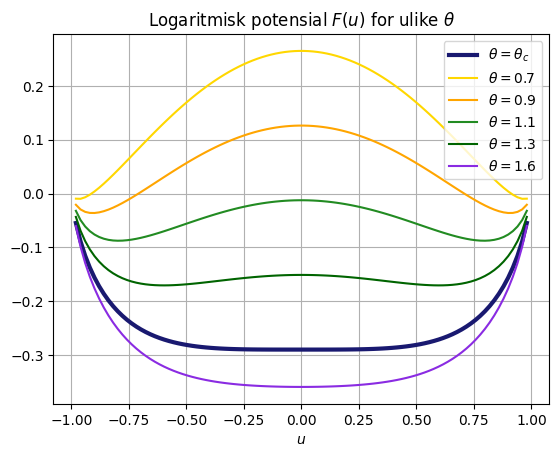

In [74]:
# Definerer det logaritmiske potensialet F(u)
def F(u, theta_c, theta):
    F = (theta_c/2)*(1-u**2) + (theta/2)*((1-u)*np.log((1-u)/2) + (1+u)*np.log((1+u)/2))
    return F

# Plotter potensialet F(u)
theta_c = 1.5
u_array = np.linspace(-1, 1, 100)[1:-1]      
theta_array = [0.7, 0.9, 1.1, 1.3, 1.6]

plt.plot(u_array, F(u_array, theta_c, theta_c), label = '$θ = θ_c$', linewidth = 3, color = 'midnightblue')
colors = ['gold', 'orange', 'forestgreen', 'darkgreen', 'blueviolet']
for i in range(len(theta_array)):
    plt.plot(u_array, F(u_array, theta_c, theta_array[i]), label = f'$θ = {theta_array[i]}$', color = colors[i])
    
plt.xlabel('$u$')
plt.title('Logaritmisk potensial $F(u)$ for ulike $θ$')
plt.grid()
plt.legend()
plt.show()

I plottet ovenfor kan man se det logaritmiske potensialet $F(u)$ for $u\in(-1,1)$ for forskjellige verdier av $\theta$ mellom $0.7$ og $1.6$. Plottet viser både eksempler der $\theta < \theta_c $, $\theta = \theta_c $ og $\theta > \theta_c $. Kurvene viser hvordan potensialet endrer seg når tempraturen varierer i forhold til den kritiske temperaturen, som i dette tilfellet er $\theta_c = 1.5$. 

For de gule tonene der $\theta \ll \theta_c$, ser vi at potensialet får en tydelig dobbelbrønnstruktur som blir dypere for lavere $\theta$. Dette indikerer at systemet foretrekker å befinne seg i de to tilsandene $u = -1$ og $u = 1$ For eksempel har kurven for $\theta = 0.7$ minima ved disse punktene.

For de grønne tonene der $\theta < \theta_c$ ser vi at brønnene gradvis blir mindre dype, og potensialets minimumspunkter beveger seg nærmere $u = 0$. For å oppnå lavest mulig potensial vil systemet fortsatt tendere mot å være fordelt i to forskjellige faser, men vi ser at de vil være mer blandet enn tidligere da potensialet ikke lenger har minimum i $u = -1$ og $u = 1$. 

Den mørkeblå grafen viser den kritiske temperaturen $\theta = \theta_c$. Denne representerer en overgang. De to brønnene er ikke lenger adskilt og potensialet er tilnærmet flatt rundt <br> $u=0$. Her vil systemet være ustabilt, da det finnes mange mulige tilstander som vil gi lavest potensial. 
Systemet vil da veksle mellom å opptre i adskilt og homogen tilstand. 

Den lilla grafen viser potensialet når $\theta > \theta_c$. Her er dobbeltbrønnene fullstendig visket ut, og potensialet får ett globalt minimum i $u = 0$. Dette representerer en homogen fase, der systemet ikke lenger vil tendere mot å skille mellom to ulike tilstander.

Generelt ser vi at stoffene vil tendere mot å dele seg i to ulike faser ved lave temperaturer under den kritiske tempraturen.
Ved høyere tempraturer vil de to potensialbrønnene bli til en felles brønn og stoffene vil blande seg mer til en homogen blanding. 

### 1.2

Vis at Cahn-Hilliard-likningen er invariant under transformasjonen $u \rightarrow -u$, det vil si at hvis $u(\vec{x}, t)$ er en løsning, så er også $-u(\vec{x}, t)$ en løsning. 

Transformajonsinvarians for $u \rightarrow -u$: 
$$

\partial_t u - \nabla(M\nabla f(u)- \kappa \Delta u) = 0 

$$

Vi starter med funksjonen: 

$$
f(u) = - \theta_c u + \frac{\theta}{2} \ln \left(\frac{1+u}{1-u}\right)
$$
Setter inn -u for u: 
$$
f(-u) = -\theta_c (-u) + \frac{\theta}{2} \ln \left(\frac{1+(-u)}{1-(-u)}\right)
= \theta_c u +\frac{\theta}{2} \ln \left(\frac{1 -u}{1+u}\right) = -f(u)
$$

Siden derivasjon er en lineær transformasjon, får vi:

$$
\partial_t(-u) - \nabla (M \nabla f(-u) - \kappa\Delta(-u)) = 0
$$
$$
-\partial_t u + \Delta (M \nabla f(u) + \kappa \Delta u) = 0 
$$
Dermed ser vi at likningen er invariant under transformasjonen $u \rightarrow -u$

 

### 1.3



Vi betrakter det rektangulære domenet:

$$\Omega = [0, L_x) \times [0, L_y) $$ 

Den totale massen er definert som: 
$\int_{\Omega}^{} u(\vec{x}, t)d\vec{x} $

Vi ønsker å vise at denne ikke endrer seg over tid:

$$
\frac{d}{dt}\int_{\Omega}^{} u(\vec{x}, t)d\vec{x} = 0 \Rightarrow\int_{\Omega}{} \partial_t u(\vec{x}, t)d\vec{x} = 0 
$$

Ved bruk av Cahn-Hillard-likningen: 

$$
\Rightarrow\int_{\Omega}{} \nabla (M\nabla\mu)d\vec{x} = 0 
$$

Ved bruk av divergensteoremet får vi: 
$$
\Rightarrow\int_{\Gamma}{} M\nabla\mu d\vec{S} = 0 

$$
Vi antar randbetingelsen: 
$$
\partial_n \mu = 0,  \Gamma \times(0, T)
$$

Dette innebærer at $\nabla\mu$  må være null på hele randområdet $\Gamma$, og dermed er massen bevart over tid. 




## Oppgave 2

I denne oppgaven implementerer vi en spektralløser for den biharmoniske likningen
\begin{aligned}
\Delta^2 u  + c u = f
\end{aligned}

på det rektangulære området $\Omega = [0,L_x)\times [0,L_y)$, med periodiske randbetingelser. <br>
I likningen over er $\Delta^2$ den biharmoniske operatoren og $c \geqslant 0$ en ikke-negativ konstant. 

<br>

I spektral-løseren Fouriertransformerer vi likningen og løser den i Fourierrommet, for så å transformere den tilbake til det fysiske rom.
\begin{aligned}
\Delta^2 u  + c u = f \quad &\xrightarrow{\mathcal{F}} \quad \widetilde{\mathbf{k}}^2 \widehat{u} + c \widehat u = \widehat f
\\
\widehat{u} &= \frac{\widehat{f}}{\widetilde{\mathbf{k}}^2 + c}
\\
\\
\widehat{u} \quad &\xrightarrow{\mathcal{F^{-1}}} \quad u
\end{aligned}


In [48]:
def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
        X (ndarray): 2D array of x-coordinates.
        Y (ndarray): 2D array of y-coordinates.
        F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
        c (float): Constant coefficient in the biharmonic equation.
        mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
        U (ndarray): 2D array representing the solution to the biharmonic equation.
    """

    N, M = F.shape
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    # Berergner grid med bølgetall
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")

    K4 = ((KX**2 + KY**2)**2)   # Beregner Poisson-operatoren
    F_hat = (fft2(F))           # Fouriertransformerer F

    # Løser likningen i Fourierrommet, forhindrer deling med 0
    with np.errstate(divide='ignore', invalid='ignore'):
        U_hat = np.where(K4 + c > 1e-10, F_hat / (K4 + c), 0.0)

    # Beregner den inverse Fouriertransformasjonen
    U = np.real((ifft2(U_hat)))

    # Behandler tilfellet c = 0
    if c < 1e-10:
        U -= np.mean(U) - mean
    return U

def smart_format(x):
    if isinstance(x, float):
        if abs(x) < 1e-2 or abs(x) > 1e4:
            return f"{x:.2e}"  # scientific
        else:
            return f"{x:.2f}"  # fixed-point
    return x

# Apply display formatting
pd.set_option('display.float_format', smart_format)

Vi ønsker å verifisere implementasjonen ved å sammenligne vår numeriske løsning med kjente eksakte løsninger, i dette tilfellet

\begin{aligned}
u(x, y) = sin(8 (x-1)) cos(4y),  \quad c = 1, \quad N_x = 4, 8, 15, 16, 20, 32, \quad N_y = 2 N_x
\\
u(x,y) =  exp(sin^2(x) + cos(2y)), \quad c = 0, \quad N_x = 4 + 4k, \quad k=0,1\ldots,9,  \quad N_y = 2N_x
\end{aligned}

In [32]:
# Bruker sympy til å beregne høyresiden f til likningen
x, y, c = sp.symbols('x y c')

# Beregner f for første eksakte løsning
u1 = sp.sin(8 * (x - 1)) * sp.cos(4 * y)
laplacian_u1 = sp.diff(u1, x, 2) + sp.diff(u1, y, 2)
biharmonic_u1 = sp.diff(laplacian_u1, x, 2) + sp.diff(laplacian_u1, y, 2)

F1 = biharmonic_u1  + c * u1
F1_simplified = sp.simplify(F1)
F1_lambdified = sp.lambdify((x, y, c), F1_simplified, "numpy")

# Beregner f for andre eksakte løsning
u2 = sp.exp(sp.sin(x)**2 + sp.cos(2*y))
laplacian_u2 = sp.diff(u2, x, 2) + sp.diff(u2, y, 2)
biharmonic_u2 = sp.diff(laplacian_u2, x, 2) + sp.diff(laplacian_u2, y, 2)

F2 = biharmonic_u2  + c * u2
F2_simplified = sp.simplify(F2)
F2_lambdified = sp.lambdify((x, y, c), F2_simplified, "numpy")

In [33]:
# Definerer funksjoner og verdier for første test-tilfelle
def U1_exact(x, y):
    return np.sin(8*(x-1))*np.cos(4*y)
 
c1 = 1
Ns = [4, 8, 15, 16, 20, 32]
F1_func = lambda X, Y: F1_lambdified(X, Y, c1)

errors = []
hs = []

for N in Ns:
    x, y = np.linspace(0, 2*np.pi, N, endpoint=False), np.linspace(0, 4*np.pi, 2*N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    F1_numeric = F1_func(X, Y)

    U1_numeric = biharmonic_solver(X, Y, F1_numeric, c1)

    max_error = np.max(np.abs(U1_numeric - U1_exact(X, Y)))     # Beregner feilen mellom numerisk og eksakt løsning
    errors.append(max_error)
    hs.append(2*np.pi / N)


# Beregner EOC
eocs = []

for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]) # Beregner EOC
    eocs.append(eoc)

# Printer resultater i tabell
print("\nKonvergenstabell, testtilfelle 1:")
df = pd.DataFrame()
df['Nt'] = Ns
df[f'L-inf error'] = errors

eoc_padded = np.append([np.nan], eocs)
df[f'EOC'] = eoc_padded

display(df)


Konvergenstabell, testtilfelle 1:


,Nt,L-inf error,EOC
0,4,6331.89,NaN
1,8,23.65,8.06
2,15,0.51,6.09
3,16,5.88e-15,497.38
4,20,4.34e-14,-8.96
5,32,6.62e-14,-0.90


Over ser man en konvergenstabell for testtilfelle 1. N viser antall punkter i x-retningen, max error viser den største feilen mellom den numeriske og eksakte løsningen, og $EOC$ viser konvergensordenen.

Høyere $EOC$, jo raskere konvergerer metoden.
Ved $N = 16$ er blir plutselig $EOC$ ekstremt høy ($EOC = 497.38$). Dette skyldes Nyquist frekvensen som sier at oppløsningen i fourier rommet må være dobbelt så stor som den høyeste frekvensen i signalet, som i dette tilfellet er 8. Det vil si at vi må ha minst 16 punkter i x-retningen for å unngå aliasing. Når man bruker $N=16$ blir resultatet maskinpresist. 
Denne feilen er det ikke mulig å forbedre, derfor ser vi at etter N=16, så blir EOC dårlig 



Konvergenstabell, testtilfelle 1:


,Nt,L-inf error,EOC
0,4,20.24,NaN
1,8,10.62,0.93
2,12,0.98,5.87
3,16,0.03,11.64
4,20,0.00,15.92
5,24,3.60e-05,18.19
6,28,1.51e-06,20.59
7,32,6.31e-08,23.76
8,36,2.53e-09,27.31
9,40,9.65e-11,31.01


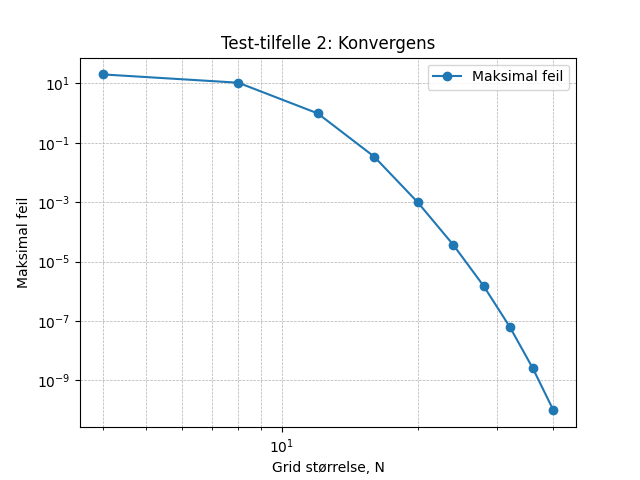

In [34]:
# Definerer funksjoner og verdier for første test-tilfelle
def U2_exact(x, y):
    return np.exp(np.sin(x)**2 + np.cos(2*y))

c2 = 0
Ns = np.arange(4, 44, 4)
F2_func = lambda X, Y: F2_lambdified(X, Y, c2)

errors = []
hs = []

for N in Ns:
    x, y = np.linspace(0, 2*np.pi, N, endpoint=False), np.linspace(0, 4*np.pi, 2*N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    F2_numeric = F2_func(X, Y)

    U2_numeric = biharmonic_solver(X, Y, F2_numeric, c2, np.mean(U2_exact(X, Y)))

    max_error = np.max(np.abs(U2_numeric - U2_exact(X, Y)))         # Beregner feilen mellom numerisk og eksakt løsning         
    errors.append(max_error)
    hs.append(2*np.pi / N)

# Beregner EOC
eocs = []
for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
    eocs.append(eoc)

# Printer resultater i tabell
print("\nKonvergenstabell, testtilfelle 1:")
df = pd.DataFrame()
df['Nt'] = Ns
df[f'L-inf error'] = errors

eoc_padded = np.append([np.nan], eocs)
df[f'EOC'] = eoc_padded

display(df)


# Plotter maksimal feil som funksjon av grid-størrelse
plt.figure()
plt.loglog(Ns, errors, marker='o', label='Maksimal feil')
plt.xlabel('Grid størrelse, N')
plt.ylabel('Maksimal feil')
plt.title('Test-tilfelle 2: Konvergens')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Over ser man en konvergenstabell for testtilfelle 2.

Her blir EOCen bedre og bedre og det er ikke noen hopp slik som i forrige oppgave. Dette er fordi funksjonen $u(x,y) =  exp(sin^2(x) + cos(2y))$ ikke kan representeres med kun sinus og cosinus bølger og vil da ha mindre og mindre feil med høyere oppløsning.

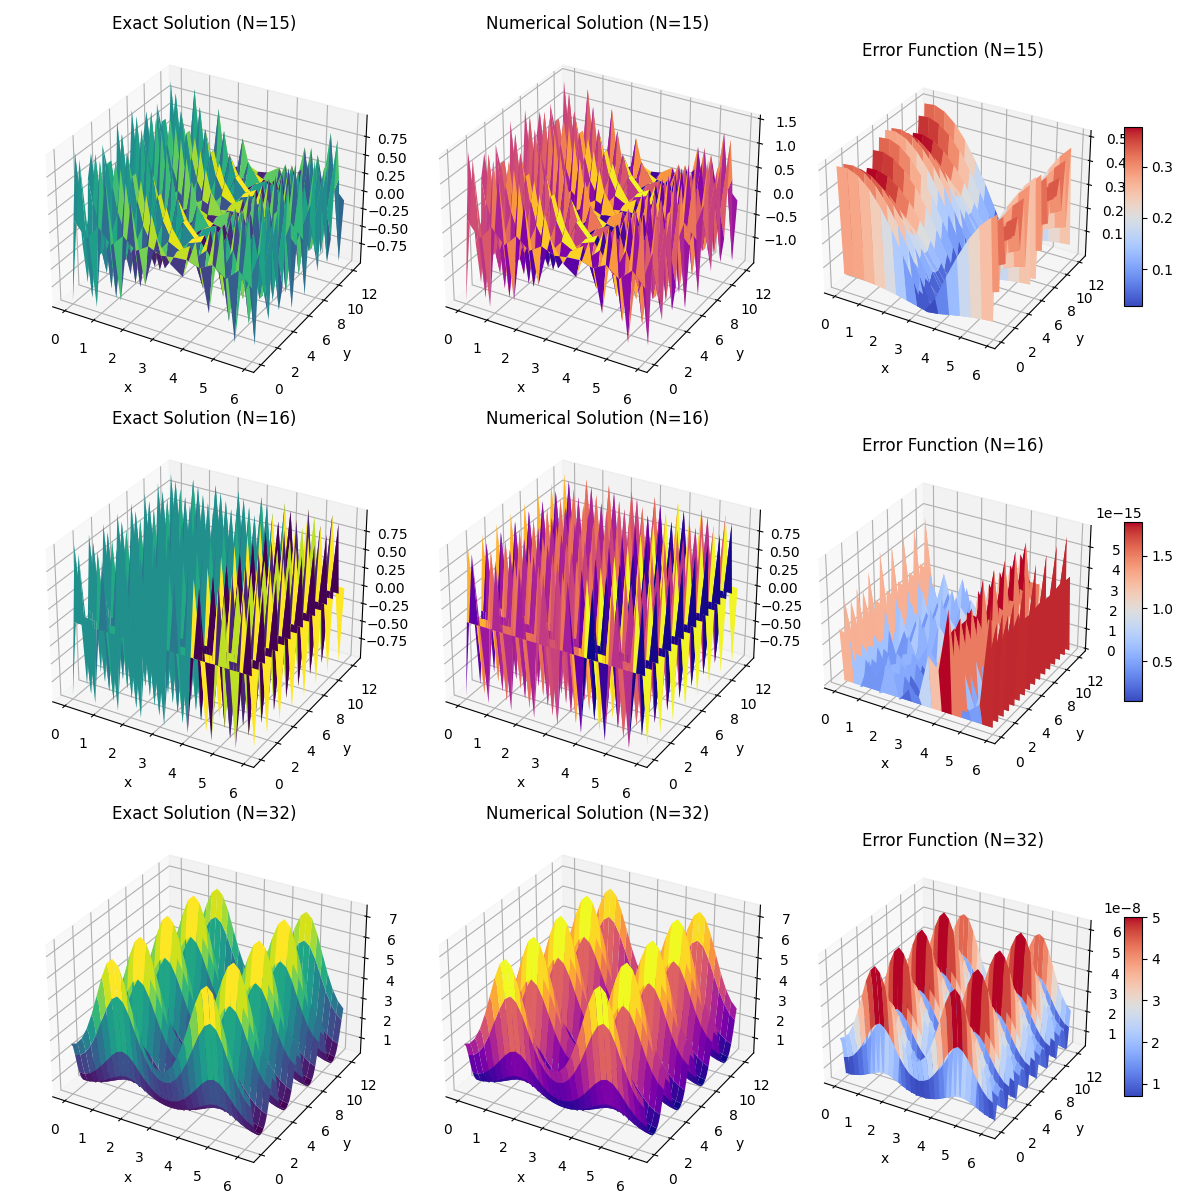

In [35]:
# Define the grid and compute solutions for N = 15, 16 (first series) and N = 32 (second series)
N_values = [15, 16, 32]
solutions = []

for N in N_values:
    x = np.linspace(0, 2 * np.pi, N, endpoint=False)
    y = np.linspace(0, 4 * np.pi, 2 * N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    if N in [15, 16]:  # First series
        F1_numeric = F1_func(X, Y)
        U1_numeric = biharmonic_solver(X, Y, F1_numeric, c1)
        U1_exact_vals = U1_exact(X, Y)
        error1 = np.abs(U1_numeric - U1_exact_vals)
        solutions.append((X, Y, U1_exact_vals, U1_numeric, error1))
    elif N == 32:  # Second series
        F2_numeric = F2_func(X, Y)
        U2_numeric = biharmonic_solver(X, Y, F2_numeric, c2, np.mean(U2_exact(X, Y)))
        U2_exact_vals = U2_exact(X, Y)
        error2 = np.abs(U2_numeric - U2_exact_vals)
        solutions.append((X, Y, U2_exact_vals, U2_numeric, error2))

# Plot the solutions
fig = plt.figure(figsize=(12, 12))

for i, (X, Y, exact, numeric, error) in enumerate(solutions):
    ax1 = fig.add_subplot(3, 3, 3 * i + 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, exact, cmap='viridis', edgecolor='none')
    ax1.set_title(f'Exact Solution (N={N_values[i]})')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')

    ax2 = fig.add_subplot(3, 3, 3 * i + 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, numeric, cmap='plasma', edgecolor='none')
    ax2.set_title(f'Numerical Solution (N={N_values[i]})')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')

    ax3 = fig.add_subplot(3, 3, 3 * i + 3, projection='3d')
    surf3 = ax3.plot_surface(X, Y, error, cmap='coolwarm', edgecolor='none')
    ax3.set_title(f'Error Function (N={N_values[i]})')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)  # Add colorbar for the error plot

plt.tight_layout()
plt.show()


Her ser man at feilen til testtilfelle 1 reduseres til maskinpresisjon med N = 16 i forhold til N = 15.  
Med testtilfelle 2 ser man at feilen øker med ekstremalpunktene til funksjonen.

## Oppgave 4

Vi skal løse likningen 
\begin{aligned} 
\partial_t u - \nabla \cdot (M \nabla (f(u) - \kappa \Delta u)) = g, \quad \Omega \times (0, T)
\end{aligned}

Her er $f(u)$ den deriverte av Helmholtz frie energitetthet 
\begin{aligned}
f(u) = F'(u) = -\theta_c u + \dfrac{\theta}{2} \ln\Bigl(\dfrac{1+u}{1-u}\Bigr)
\end{aligned}
der $\theta$ er temperaturen og $\theta_c$ er den kritiske temperaturen der blandingen går fra stabil til ustabil.

For å unngå utfordringer knyttet til de logaritmiske leddene blir $F(u)$ gjerne regularisert og approksimert til 
\begin{aligned}
F(u) = \dfrac{1}{4}(u^2 - 1)^2, \quad \text{som gir } \quad f(u) = u^3 - u.
\end{aligned}

Dersom vi antar $M = 1$ får vi følgende likning
\begin{aligned} 
\partial_t u - \kappa \Delta^2u - \Delta(u^3 - u) = g
\end{aligned}

$\partial_t u$, $\kappa \Delta^2u$ og $\Delta u$ er lineære ledd som skal behandles implisitt, mens $\Delta u^3$ er ikke-lineær og skal behandles eksplisitt. $g$ skal også behandles implisitt.

For å unngå uheldige fortegn splitter vi opp den ikke-lineære delen på følgende måte
\begin{aligned}
\Delta (u^3 -u) = 
\underbrace{a\Delta u}_{f_1(u)} + \underbrace{\Delta u^3 -(1+a) \Delta u}_{f_2(u)}.
\end{aligned}

der vi behandler $f_1(u)$ implisitt og $f_2(u)$ eksplisitt. 


Vi samler leddene som skal behandles implisitt på venstre side og leddene som skal behandles eksplisitt på høyre side og får
$$
\partial_t u - \kappa \Delta^2u - a \Delta u - g = \Delta u^3 - (1 + a) \Delta u
$$

Dette gir oss følgende IMEX-metode

\begin{aligned}
\dfrac{u^{n+1} - u^n}{\tau} +\kappa \Delta^2 u^{n+1}  - a \Delta u^{n+1} - g^{n+1} &= \Delta \bigl( (u^n)^3 - (1+a) u^n\bigr)
\\
\\
u^{n+1} +\tau (\kappa \Delta^2 u^{n+1}  - a \Delta u^{n+1}) - \tau g^{n+1} &= u^n + \tau \Delta \bigl( (u^n)^3 - (1+a) u^n\bigr)
\end{aligned}

Deretter transformer vi likningen til Fourier-rommet
\begin{aligned}
\widehat{u}^{n+1} +\tau (\kappa \widetilde{\mathbf{k}}^4 u^{n+1}  - a \widetilde{\mathbf{k}}^2 u^{n+1}) - \tau \widehat{g}^{n+1} 
&= u^n + \tau \widetilde{\mathbf{k}}^2 \widehat{(u^n)^3 - (1+a) u^n}
\end{aligned}

Merk at vi beholder $\widehat{(u^n)^3 - (1+a) u^n}$ på denne formen da dette skal løses i det fysiske rom og deretter transformeres. 

Ved å løse for $\widehat{u}^{n+1}$ får vi et uttrykk for den nye løsningen i Fourier-rommet:
\begin{aligned}
\widehat{u}^{n+1} = \frac{\widehat{u}^n + \tau (\widetilde{\mathbf{k}}^2 \widehat{(u^n)^3 - (1+a) u^n} + \widehat g)}
{1 + \tau (\kappa \widetilde{\mathbf{k}}^4 - a \widetilde{\mathbf{k}}^2)}
\end{aligned}

In [49]:
def cahn_hilliard_backward_euler(*, 
                                kappa, 
                                X, Y, U0, 
                                t0, T, Nt,
                                g, 
                                alpha=1.5):
    
    
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method 
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    # Definerer relevant data for Fouriertransformen
    N, M = U0.shape 
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    # Beregner grid med bølgetall
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")

    K2 = -(KX**2 + KY**2)
    K4 = K2**2

    # Beregner diskret Fouriertransform av initialverdien
    U_hat = fft2(U0)

    # Beregner tidssteg 
    t = t0 
    dt = (T-t0)/Nt

    yield U_hat, t  

    # Løser likningen for hvert tidssteg
    while t < T-dt/2:
        # Behandler funksjonsparameter g 
        if g is not None:
            g_hat = fft2(g(X, Y, t + dt))                           # g skal behandles implisitt, bruker t + dt
        else:
            g_hat = 0
    
        
        U_lin = (ifft2(U_hat))**3 - (1+alpha)*(ifft2(U_hat))        # Finner lineær del i det fysiske rom
        U_lin_hat = fft2(U_lin)                                     # Finner lineær del i Fourierrommet 

        denominator = 1 + dt*(kappa*K4 - alpha*K2)
        numerator = U_hat + dt*(K2*U_lin_hat + g_hat)
        U_hat = numerator/denominator                               # Beregner løsningen i Fourierrommet

        # Update time
        t += dt

        yield U_hat, t


Vi ønsker å verifisere implementasjonen ved å sammenligne vår numeriske løsning med en kjent eksakt løsningen, i dette tilfellet
\begin{aligned}
u_{ex} = sin(x) \cdot cos(x) \cdot e^{-4 \kappa t}
\end{aligned}

In [50]:
# Definerer eksakt løsning
def U_ex(x, y, t, kappa):
    return np.sin(x) * np.cos(y) * np.exp(-4*kappa*t)

# Definerer to ulike verdier for kappa
kappa_value1 = 1
kappa_value001 = 0.01

# Bruker sympy til å beregne høyresiden g til likningen
x, y, t, kappa = sp.symbols("x y t kappa")
u_ex = sp.sin(x) * sp.cos(y) * sp.exp(-4*kappa*t)
laplacian_u = sp.diff(u_ex, x, 2) + sp.diff(u_ex, y, 2)
biharmonic_u = sp.diff(laplacian_u, x, 2) + sp.diff(laplacian_u, y, 2)
nonlinear = sp.diff(u_ex**3 - u_ex, x, 2) + sp.diff(u_ex**3 - u_ex, y, 2)
g = sp.diff(u_ex, t) + kappa * biharmonic_u - nonlinear
g_simplified = sp.simplify(g)

# Beregner to ulike høyresider g for to ulike kappa
g_lambdify1 = sp.lambdify((x, y, t), g_simplified.subs(kappa, kappa_value1), "numpy")
g_func1 = lambda X, Y, t: g_lambdify1(X, Y, t)
g_lambdify001 = sp.lambdify((x, y, t), g_simplified.subs(kappa, kappa_value001), "numpy")
g_func001 = lambda X, Y, t: g_lambdify001(X, Y, t)

In [52]:
t0, T = 0, 1
Nts = [100, 200, 400, 800, 1600, 3200]

N = 64
x, y = np.linspace(0, 16*np.pi, N, endpoint=False), np.linspace(0, 16*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)


# Beregninger med kappa = 1
kappa_value = 1

errors = []         # Liste til feilverdier
hs = []             # Liste til korresponderende steglengde

for Nt in Nts:      # Itererer gjennom ulike Nt
    dt = (T - t0) / Nt
    U0 = U_ex(X, Y, 0, kappa_value)
    solver = cahn_hilliard_backward_euler(kappa=kappa_value, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, g = g_func1, alpha=1.5)
    max_error = 0

    for Uhat, t in solver:
        U = ifft2(Uhat).real
        new_error = np.max(np.abs(U - U_ex(X, Y, t, kappa_value))) # Beregner feilen mellom numerisk løsning og eksakt løsning

        if new_error > max_error:
            max_error = new_error
    
    errors.append(max_error)    # Lagrer feilen i liste
    hs.append(dt)               # Lagrer steglengde i liste


# Beregner EOC
eocs = []                       # Liste til EOC-verdier

for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])     # Beregner EOC
    eocs.append(eoc)                                                    # Legger til EOC i liste

# Printer resultater i tabell
print("\nKonvergenstabell")
df = pd.DataFrame()
df['Nt'] = Nts
df[f'L-inf error'] = errors

eoc_padded = np.append([np.nan], eocs)
df[f'EOC'] = eoc_padded

display(df)


# Beregninger med kappa = 0.01
kappa_value = 0.01

errors = []     # Liste med feilverdier
hs = []         # Liste med tidssteg

for Nt in Nts:  # Itererer gjennom ulike Nt
    dt = (T - t0) / Nt
    U0 = U_ex(X, Y, 0, kappa_value)
    solver = cahn_hilliard_backward_euler(kappa=kappa_value, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, g = g_func001, alpha=1.5)
    max_error = 0

    for Uhat, t in solver:
        U = ifft2(Uhat).real
        new_error = np.max(np.abs(U - U_ex(X, Y, t, kappa_value)))  # Beregner feilen mellom numerisk løsning og eksakt løsning
        
        if new_error > max_error:
            max_error = new_error
    
    errors.append(max_error)
    hs.append(dt)

# Beregner EOC
eocs = []       # Liste til EOC-verdier

for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]) # Beregner EOC
    eocs.append(eoc)                                                # Legger til EOC i liste

# Printer resultater i tabell
print("\nKonvergenstabell")
df = pd.DataFrame()
df['Nt'] = Nts
df[f'L-inf error'] = errors

eoc_padded = np.append([np.nan], eocs)
df[f'EOC'] = eoc_padded

display(df)


Konvergenstabell


,Nt,L-inf error,EOC
0,100,0.02,NaN
1,200,0.01,0.97
2,400,6.35e-03,0.99
3,800,3.19e-03,0.99
4,1600,1.60e-03,1.00
5,3200,8.00e-04,1.00



Konvergenstabell


,Nt,L-inf error,EOC
0,100,3.16e-03,NaN
1,200,1.74e-03,0.86
2,400,9.18e-04,0.92
3,800,4.72e-04,0.96
4,1600,2.39e-04,0.98
5,3200,1.21e-04,0.99


Tabellene over viser at den eksperimentelle konvergensordenen til implisitt Euler metode konvergerer mot $p = 1$. 
Dette stemmer godt overens med den teoretiske konvergensordenen til metoden, som er nettopp $p = 1$. 

Av tabellen over ser vi at den maksimale feilen er mindre for $\kappa = 0.01$ enn for $\kappa = 1$. 
Dette er å forvente da løsningen av testlikningen $u_{ex} = sin(x) cos(x) e^{-4 \kappa t}$ vil endre seg mindre for hvert tidssteg når $\kappa$ er liten. Det er da naturlig at en høyere $\kappa$ også vil gi større feil i den numeriske approksimasjonen. 

EOC-verdien avhenger derimot ikke av størrelsen på maksimalfeilen selv, men heller av hvor raskt feilen avtar når man raffinerer metoden.
Vi ser at EOC konvergerer raskere for $\kappa = 1$ enn for $\kappa = 0.01$. <br>
Med lignende argumentasjon som over kan man forsvare at eksperimentell konvergensorden vil konvergere saktere når $\kappa$ er liten. 
Når den absolutte feilen er mindre i utgangspunktet, vil en endring i tidssteget gi mindre utslag enn hvis feilen er stor fra steg til steg. 
Forskjellen i feil mellom løsninger med $\tau$ og $\frac{\tau}{2}$ altså være vesentlig større for en approksimasjon som i utgangspunktet har større feil, slik som for $\kappa = 1$. 
<br>
I tillegg kan man studere uttrykket brukt i den numeriske metoden
\begin{aligned}
u^{n+1} +\tau (\kappa \Delta^2 u^{n+1}  - a \Delta u^{n+1}) - \tau g^{n+1} &= u^n + \tau \Delta \bigl( (u^n)^3 - (1+a) u^n\bigr)
\end{aligned}

I uttrykket over bestemmer $\kappa$ vektingen av det biharmoniske leddet i utregningen av det neste tidssteget. 
Dersom $\kappa = 0.01$ vektes dette leddet svært lite relativt til de andre leddene og den eksplisitte delen av likningen vil gi større utslag.
Eksplisitte metoder stiller generelt strengere krav til steglengden enn implisitte metoder, og det gir dermed mening at EOC vil konvergere saktere når den eksplisitte delen av uttrykket vektes mer. 

## Oppgave 5

Ved å benytte Song-metoden på den Fouriertransformerte Cahn-Hilliard ligningen får vi

$$
\hat{U}^{(1)} = \hat{U}^n + \tau \left[ (\alpha \left| k \right|^2 - \kappa \left| k \right|^4 ) \hat{U}^{(1)} + \widehat{\mathcal{N}(U^n)} \right]
$$

$$
\hat{U}^{(2)} = \alpha_{10} \hat{U}^n + \alpha_{11} \hat{U}^{(1)} + \beta_1 \tau \left[ (\alpha \left| k \right|^2 - \kappa \left| k \right|^4 ) \hat{U}^{(2)} + \widehat{\mathcal{N}(U^{(1)})} \right]
$$

$$
\hat{U}^{(n+1)} = \alpha_{20} \hat{U}^n + \alpha_{21} \hat{U}^{(1)} + \alpha_{22} \hat{U}^{(2)} + \beta_2 \tau \left[ (\alpha \left| k \right|^2 - \kappa \left| k \right|^4 ) \hat{U}^{(n+1)} + \widehat{\mathcal{N}(U^{(2)})} \right]
$$

Hvor $\mathcal{N}(U) = \Delta U^3 - (1 + a) \Delta U$. <br>
Deretter legger vi til $\tau \beta_i \hat{g}(x, y, t + \frac{\tau}{2})$ på høyresiden. Ved å løse for de ukjente får vi

$$
\hat{U}^{(1)} = \frac{\hat{U}^n + \tau \widehat{\mathcal{N}(U^n)} + \tau \hat{g}(x, y, t + \frac{\tau}{2})}{(1 + \tau (\kappa \left| k \right|^4 - \alpha \left| k \right|^2)) }
$$
  
$$
\hat{U}^{(2)} = \frac{\alpha_{10} \hat{U}^n + \alpha_{11} \hat{U}^{(1)} + \beta_1 \tau \widehat{\mathcal{N}(U^{(1)})} + \beta_1 \tau \hat{g}(x, y, t + \frac{\tau}{2})}{(1 + \beta_1 \tau (\kappa \left| k \right|^4 - \alpha \left| k \right|^2)) }
$$
  
$$
\hat{U}^{(n+1)} = \frac{\alpha_{20} \hat{U}^n + \alpha_{21} \hat{U}^{(1)} + \alpha_{22} \hat{U}^{(2)} + \beta_2 \tau \widehat{\mathcal{N}(U^{(2)})} + \beta_2 \tau \hat{g}(x, y, t + \frac{\tau}{2})}{(1 + \beta_2 \tau (\kappa \left| k \right|^4 - \alpha \left| k \right|^2))}
$$



In [54]:
def IMEX_solver(*, 
                                kappa, 
                                X, Y, U0, 
                                t0, T, Nt,
                                g, coeff,
                                alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method 
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    # Definerer relevant data for Fouriertransformen
    N, M = U0.shape
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    alpha_10, alpha_11, alpha_20, alpha_21, alpha_22, beta_1, beta_2 = coeff  # Henter ut koeffisientene

    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")
    K2 = -(KX**2 + KY**2)
    K4 = K2**2

    # Beregner diskret Fouriertransform av initialverdi
    U_hat = fft2(U0)

    # Beregner tidssteg
    t = t0 
    dt = (T-t0)/Nt

    yield U_hat, t  

    
    while t < T-dt/2:
        
        # Behandler funksjonsparameter g 
        if g is not None:
            g_hat = fft2(g(X, Y, t + dt/2, kappa))
        else:
            g_hat = 0
        
        def NonLinear(U_hat):
            U = ifft2(U_hat).real
            NonLin = U**3 - (1 + alpha) * U
            return K2*fft2(NonLin)

        # Bruker Song-metoden til å finne neste steg
        U_hat_1 = (U_hat + dt * (NonLinear(U_hat) + g_hat)) / (1 + dt * (kappa * K4 - alpha * K2))
        U_hat_2 = (alpha_10 * U_hat + alpha_11 * U_hat_1 + beta_1 * dt * (NonLinear(U_hat_1) + g_hat)) / (1 + beta_1 * dt * (kappa * K4 - alpha * K2))
        U_hat_next = (alpha_20 * U_hat + alpha_21 * U_hat_1 + alpha_22 * U_hat_2 + beta_2 * dt * (NonLinear(U_hat_2) + g_hat)) / (1 + beta_2 * dt * (kappa * K4 - alpha * K2))
       
        # Oppdaterer U_hat og t
        U_hat = U_hat_next
        t += dt

        yield U_hat, t

In [55]:
# Definerer eksakt løsning
def U_ex(x, y, t, kappa):
    return np.sin(x) * np.cos(y) * np.exp(-4*kappa*t)

# Bruker sympy til å beregne høyresiden g til likningen
x, y, t, kappa = sp.symbols("x y t kappa")
u_ex = sp.sin(x) * sp.cos(y) * sp.exp(-4*kappa*t)
laplacian_u = sp.diff(u_ex, x, 2) + sp.diff(u_ex, y, 2)
biharmonic_u = sp.diff(laplacian_u, x, 2) + sp.diff(laplacian_u, y, 2)
nonlinear = sp.diff(u_ex**3 - u_ex, x, 2) + sp.diff(u_ex**3 - u_ex, y, 2)
g = sp.diff(u_ex, t) + kappa * biharmonic_u - nonlinear
g_simplified = sp.simplify(g)

# Beregner høyresiden g for 
g_lambdify001 = sp.lambdify((x, y, t, kappa), g_simplified, "numpy")
g_func = lambda X, Y, t, kappa: g_lambdify001(X, Y, t, kappa)

In [61]:
t0, T = 0, 1
Nts = [100, 200, 400, 800, 1600, 3200]
kappa = 0.01

N = 64
x, y = np.linspace(0, 16*np.pi, N, endpoint=False), np.linspace(0, 16*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# Definerer 4 sett med koeffisienter
coeff_1 = (3/2, -1/2, 0, 0, 1, 1/2, 1)
coeff_2 = (2, -1, 1/2, 0, 1/2, 1, 1)
coeff_3 = (2, -1, 0, 1/2, 1/2, 1, 1/2)
coeff_4 = (5/2, -3/2, 2/3, 0, 1/3, 3/2, 1)

for coeff_indeks, coeff in zip([1, 2, 3, 4], [coeff_1, coeff_2, coeff_3, coeff_4]):
    
    U0 = U_ex(X, Y, 0, kappa)
    errors = []                     # Liste til feilverdier
    hs = []                         # Liste til korresponderende steglengde

    for Nt in Nts:
        dt = (T - t0) / Nt
        solver = IMEX_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, g = g_func, alpha=1.5, coeff = coeff)
        max_error = 0

        for Uhat, t in solver:
            U = ifft2(Uhat).real
            new_error = np.max(np.abs(U - U_ex(X, Y, t, kappa)))    # Beregner feilen mellom numerisk løsning og eksakt løsning

            if new_error > max_error:
                max_error = new_error
        
        errors.append(max_error)
        hs.append(dt)

    # Beregner EOC
    eocs = []                       # Liste til EOC-verdier

    for i in range(1, len(errors)):
        eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])     # Beregner EOC
        eocs.append(eoc)                                                    # Legger til EOC i liste

    # Printer resultater i tabell
    print(f"Konvergenstabell for koeffisienter:")
    print(f"a_10 = {coeff[0]:.2f}, a_11 = {coeff[1]:.2f}, a_20 = {coeff[2]:.2f}, a_21 = {coeff[3]:.2f},\na_22 = {coeff[4]:.2f}, b_1 = {coeff[5]:.2f}, b_2 = {coeff[6]:.2f}")
    df = pd.DataFrame()
    df['Nt'] = Nts
    df[f'L-inf error'] = errors

    eoc_padded = np.append([np.nan], eocs)
    df[f'EOC'] = eoc_padded

    display(df)

Konvergenstabell for koeffisienter:
a_10 = 1.50, a_11 = -0.50, a_20 = 0.00, a_21 = 0.00,
a_22 = 1.00, b_1 = 0.50, b_2 = 1.00


,Nt,L-inf error,EOC
0,100,8.37e-05,NaN
1,200,2.16e-05,1.96
2,400,5.41e-06,2.00
3,800,1.35e-06,2.01
4,1600,3.35e-07,2.01
5,3200,8.37e-08,2.00


Konvergenstabell for koeffisienter:
a_10 = 2.00, a_11 = -1.00, a_20 = 0.50, a_21 = 0.00,
a_22 = 0.50, b_1 = 1.00, b_2 = 1.00


,Nt,L-inf error,EOC
0,100,2.00e-05,NaN
1,200,8.93e-06,1.16
2,400,2.95e-06,1.60
3,800,8.43e-07,1.81
4,1600,2.25e-07,1.91
5,3200,5.81e-08,1.95


Konvergenstabell for koeffisienter:
a_10 = 2.00, a_11 = -1.00, a_20 = 0.00, a_21 = 0.50,
a_22 = 0.50, b_1 = 1.00, b_2 = 0.50


,Nt,L-inf error,EOC
0,100,7.90e-05,NaN
1,200,2.08e-05,1.93
2,400,5.29e-06,1.97
3,800,1.33e-06,1.99
4,1600,3.33e-07,2.00
5,3200,8.34e-08,2.00


Konvergenstabell for koeffisienter:
a_10 = 2.50, a_11 = -1.50, a_20 = 0.67, a_21 = 0.00,
a_22 = 0.33, b_1 = 1.50, b_2 = 1.00


,Nt,L-inf error,EOC
0,100,1.15e-04,NaN
1,200,3.85e-05,1.58
2,400,1.12e-05,1.78
3,800,3.02e-06,1.89
4,1600,7.83e-07,1.94
5,3200,2.00e-07,1.97


Tabellene over viser en oversikt over maksimal feil og EOC avhengig av antall tidssteg $N_t$ for fire ulike sett med Song-koeffisienter. 

Vi ser at Song-metoden har en eksperimentell konvergensorden på $p = 2$ for alle koeffisientene. I oppgave 4 så vi at implisitt Euler metode hadde en EOC på $p = 1$. Dette impliserer at Song-metoden er betraktelig mer effektiv enn implisitt Euler, da den samme feiltoleransen vil kunne oppnås med færre tidssteg ved å ta i bruk Song-metoden. 

Vi ser at det første settet med Song-koeffisienter, 
\begin{aligned}
\alpha_{10} = \frac{3}{2}, \quad \alpha_{11} = - \frac{1}{2}, \quad \alpha_{20} = 0, \quad \alpha_{21} = 0, \quad \alpha_{22} = 1, \quad \beta_1 = - \frac{1}{2}, \quad \beta_2 = 1
\end{aligned}

gir høyest og raskest konvergerende eksperimentell konvergensorden. Disse koeffisientene vil altså oppfylle Song-metodens potensiale raskere enn de andre. 

I neste oppgave vil vi derfor benytte Song-metoden med det første settet med Song-koeffisienter for å løse Cahn-Hilliard likningen.

## Oppgave 6

In [62]:
kappa = 0.0025**2
coeff = (3/2, -1/2, 0, 0, 1, 1/2, 1)

Lx, Ly = 0.5, 0.5                                   # Definerer området
Nx, Ny = 256, 256                                   # Definerer oppløsning
dA = Lx/Nx * Ly/Ny                                  # Definerer arealelement
x, y = np.linspace(0, Lx, Nx, endpoint = False), np.linspace(0, Ly, Ny, endpoint = False)     
X, Y = np.meshgrid(x, y)                            # Oppretter grid

# Definerer liste med to ulike tidsintervall
t0 = 0
intervals = np.array([4.0, 0.01])                        

# Definerer liste med to ulike initialbetingelser
rng = np.random.default_rng(12345)
noise_1 = 0.05
u0_base_1 = 0.0
U0_1 = np.ones_like((Ny, Nx))
U0_1 = np.full((Ny, Nx), u0_base_1) +  noise_1*rng.standard_normal((Ny, Nx))

noise_2 = 0.05
u0_base_2 = -0.45
U0_2 = np.ones_like((Ny, Nx))
U0_2 = np.full((Ny, Nx), u0_base_2) +  noise_2*rng.standard_normal((Ny, Nx))

U0s = np.array([U0_1, U0_2])

# Definerer liste med to ulike steglengder
dts = np.array([10**(-3), 10**(-4)])                

In [63]:
# Definerer nødvendige funksjoner

def total_mass(U):
    return np.sum(U)*dA

def F(u):                               # Definerer funksjon for Helmholtz frie energitetthet F(u)
    return (1/4)*(u**2 - 1)**2

def mixing_energy(U):                   # Definerer funksjon for blandingsenergi
    return np.sum(F(U))*dA              # Evaluerer F(u) i U og summerer over hele gridet


def interface_energy(kappa, U, Nx, Ny, Lx, Ly):     # Definerer funksjon for grenseflateenergi
    U_hat = fft2(U)

    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    # Beregner kvadratet av gradienten til u
    U_hat_x = 1j*KX * U_hat
    U_hat_y = 1j*KY * U_hat
    U_x = ifft2(U_hat_x).real
    U_y = ifft2(U_hat_y).real

    U_grad_squared = U_x**2 + U_y**2
    
    int_energy = np.sum((kappa/2)*U_grad_squared) * dA

    return int_energy

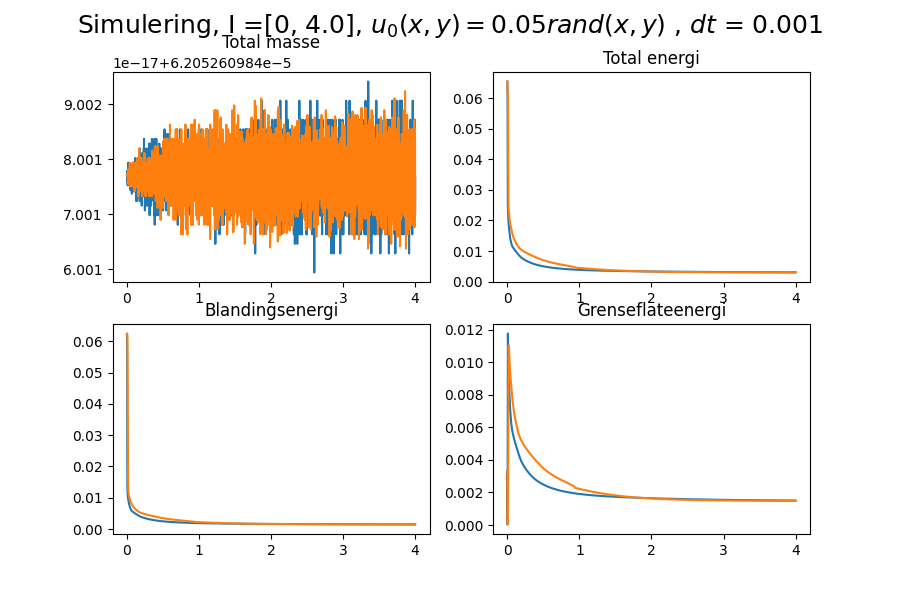

KeyboardInterrupt: 

In [64]:
# Henter verdier med de to forskjellige løserene
solver1 =lambda T, U0, dt: IMEX_solver(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g=None, coeff=coeff)
solver2 =lambda T, U0, dt: cahn_hilliard_backward_euler(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g=None)

# Oppretter tomme lister
html_output=[]
total_mass_list = [[], []]
mixing_energy_list = [[], []]
interface_energy_list = [[], []]
times_list = [[], []]

for T, U0, dt in [(intervals[0], U0s[0], dts[0]), (intervals[0], U0s[1], dts[0]),(intervals[1], U0s[0], dts[0]), (intervals[1], U0s[0], dts[1]), (intervals[1], U0s[1], dts[1])]:
    
    # Løser med IMEX-løseren
    for i, (U_hat, t) in enumerate(solver1(T, U0, dt)):
        
        # Regner ut og legger inn masse og energi
        U = ifft2(U_hat).real

        times_list[0].append(t)
        total_mass_list[0].append(total_mass(U))
        mixing_energy_list[0].append(mixing_energy(U))
        interface_energy_list[0].append(interface_energy(kappa, U, Nx, Ny, Lx, Ly))

    # Løser med implisitt Euler-løseren
    for i, (U_hat, t) in enumerate(solver2(T, U0, dt)):
        
        # Regner ut og legger inn masse og energi
        U = ifft2(U_hat).real

        times_list[1].append(t)
        total_mass_list[1].append(total_mass(U))
        mixing_energy_list[1].append(mixing_energy(U))
        interface_energy_list[1].append(interface_energy(kappa, U, Nx, Ny, Lx, Ly))
        

    # For IMEX
    times_list1 = np.array(times_list[0])
    total_mass_list1 = np.array(total_mass_list[0])
    mixing_energy_list1 = np.array(mixing_energy_list[0])
    interface_energy_list1 = np.array(interface_energy_list[0])
    total_energy_list1 = mixing_energy_list1 + interface_energy_list1

    # For implisitt Euler
    times_list2 = np.array(times_list[1])
    total_mass_list2 = np.array(total_mass_list[1])
    mixing_energy_list2 = np.array(mixing_energy_list[1])
    interface_energy_list2 = np.array(interface_energy_list[1])
    total_energy_list2 = mixing_energy_list2 + interface_energy_list2

    # Plotter total masse, blandingsenergi, grenseflateenergi og total energi
    fig, axs = plt.subplots(2, 2, figsize=(9, 6))
    if np.array_equal(U0, U0s[0]):
        fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)
    else:
        fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = -0.45 + 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)

    axs[0][0].plot(times_list1, total_mass_list1)
    axs[0][0].plot(times_list2, total_mass_list2)
    axs[0][0].set_title('Total masse')

    axs[1][0].plot(times_list1, mixing_energy_list1)
    axs[1][0].plot(times_list2, mixing_energy_list2)
    axs[1][0].set_title('Blandingsenergi')

    axs[1][1].plot(times_list1, interface_energy_list1)
    axs[1][1].plot(times_list2, interface_energy_list2)
    axs[1][1].set_title('Grenseflateenergi')

    axs[0][1].plot(times_list1, total_energy_list1)
    axs[0][1].plot(times_list2, total_energy_list2)
    axs[0][1].set_title('Total energi')

    plt.show()

Man ser at den totale massen ikke endrer seg over tid, siden det er et lukket system. Variasjonene i plottet skyldes numerisk støy. <br> 

Blandings- og grenseflateenergien ser man tydeligst i plottene med <!-- $dt = 10^{-4}$ og --> $I = [0, 0.01]$. Her kan man se at grenseflateenergien, som avhenger av gradienten til konsentrasjonen, er neglisjerbar i begynnelsen. Deretter skyter den fort opp, siden partiklene samler seg mer og mer under spinoidal dekomponering, og så minker den stabilt når grenseflatene blir mindre og mindre.

Blandingsenergien starter høyest, siden det er en homogen blanding, og minker stabilt når partiklene begynner å konsentrere seg under dekomponeringen.  
Når $dt = 10^{-3}$ skjer spinoidal dekomponering senere. Dette skjer fordi utregningen av $u(x, y, t)$ blir mindre presis og da bruker løseren mer tid på å reagere på endring.  

Det er også en betydelig forskjell mellom de to startbetingelsene. Når $u_0$ har cirka like mye av hver partikkel begynner dekomponeringen fortere fordi det er "lettere" for partiklene å samle seg. Når det er høyere konsentrasjon av den ene partikkelen, må stoffet med lavere konsentrasjon bruke mer tid på å samle seg.  

I grafene er implisitt Euler-løseren gul og Song metode-løseren blå, og man kan se at implisitt Euler-løseren gir en tregere dekomponering enn Song metode-løseren da denne er mindre stabil.   

For startbetingelsen med like konsentrasjoner $u_0^1 = 0.05\cdot rand(x, y)$ starter dekomponeringen omkring $t = 5\cdot 10^{-5}$. For startbetingelsen med den mer forskyvede konsentrasjonen  
$u_0^2 = -0.45 + 0.05\cdot rand(x, y)$ starter dekomponeringen omkring $t = 0.001$.  
Ostwald modningen er fra topppunktet på grenseflateenergien, som for $u_0^1$ er ved $t = 0.001$. For $u_0^2$ skjer dette ved $t = 0.002$. Da går reaksjonen langsommere og går mot likevekt (liten endring i energien) etter $t = 1$ for $u_0^1$ og $t = 2$ for $u_0^2$.

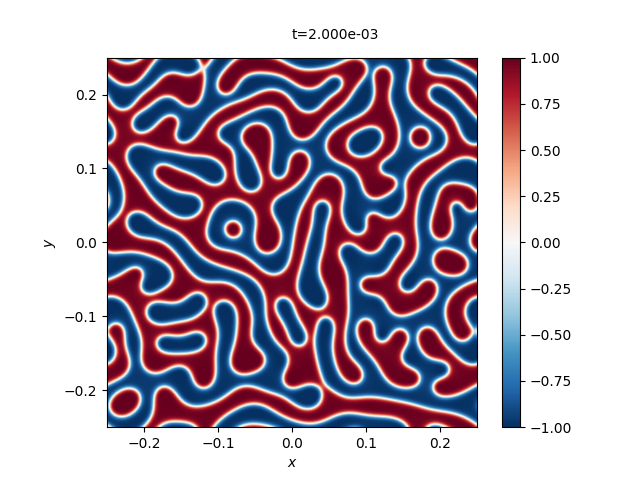

In [ ]:
# Ser nærmere på spinoidal dekomponering og Ostwald modning

# Setter startbetingelser
t0 = 0
T = 0.002   
Nt = 40000
dt = (T - t0)/Nt
U0 = U0s[0]

solver1 =lambda T, U0, dt: IMEX_solver(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g=None, coeff=coeff)


# Lager en liste med hvilke bilder man skal hente ut, som tar flere bilder på starten og mindre etterhvert.
list_length = 20 - 7
x = np.linspace(0.3, 1, list_length)
x_scaled = (x**5) * N
integer_list = np.round(x_scaled).astype(int).tolist()
snapshot_times = [0, 1, 2, 3, 4, 6, 8] + sorted(set(integer_list))

# Kjører simulasjonen for kun IMEX løseren
snapshot_times_and_us = []
for i, (U_hat, t) in enumerate(solver1(T, U0, dt)):   
    # Henter ut visse bilder av løsningen
    U = ifft2(U_hat).real
    for snapshot_time in snapshot_times:
        if i in snapshot_times:
            snapshot_times_and_us.append((U, t))
            break

ani = pt.create_animation(snapshot_times_and_us, Lx, Ly);
html_output_detailed = HTML(ani.to_jshtml())

#### Legger 5 bilder av spinoidal dekomponering og ostwald modning inn i en html

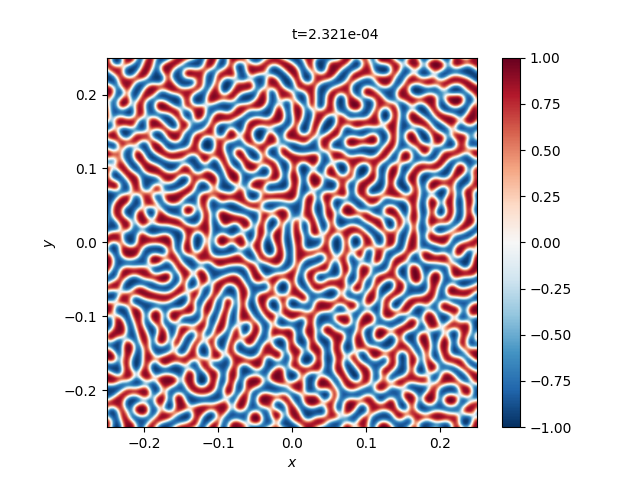

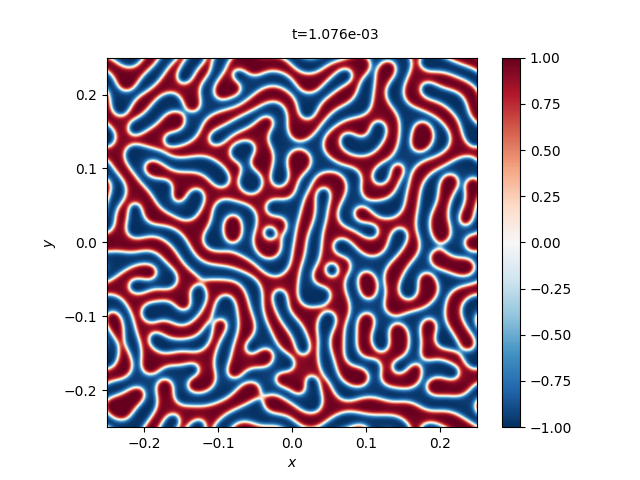

In [ ]:
# Vi fant ikke ut hvordan man unngikk å plotte heatmappet her, så se ibort ifra de
spinoidal_decompostion = [(snapshot_times_and_us[i][0], snapshot_times_and_us[i][1]) for i in [9, 10, 11, 12, 13]]
ani_spinoidal = pt.create_animation(spinoidal_decompostion, Lx, Ly)
html_output_spinoidal = HTML(ani_spinoidal.to_jshtml())

ostwald_ripening = [(snapshot_times_and_us[i][0], snapshot_times_and_us[i][1]) for i in [13, 14, 15, 16, 17]]
ani_ostwald = pt.create_animation(ostwald_ripening, Lx, Ly)
html_output_ostwald = HTML(ani_ostwald.to_jshtml())

#### Bildesekvens av dekomponering og modning

In [ ]:
html_output_spinoidal

In [ ]:
html_output_ostwald

Her kan man se at de starter å samle seg ved $t = 5\cdot 10^{-5}$ og begynner modningen ved $t = 2\cdot 10^{-4}$